In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
# If you have a CSV from previous steps:
master_df_enhanced = pd.read_csv('enhanced_game_investment_dataset.csv')
# Or, run your feature engineering code here to create master_df_enhanced

# Assume your enhanced DataFrame is called master_df_enhanced
target_col = 'enhanced_engagement_score'
leakage_features = [
    'twitch_total_viewers', 'youtube_total_views', 'reddit_total_score',
    'cross_platform_engagement_rate', 'viral_potential_score'
]

# Build feature list: remove leakage, target, and text columns
features = [
    col for col in master_df_enhanced.columns
    if col not in leakage_features + [target_col, 'investment_potential', 'game_title']
    and pd.api.types.is_numeric_dtype(master_df_enhanced[col])
]

# Prepare X and y
X = master_df_enhanced[features].copy()
y = master_df_enhanced[target_col].copy()

# Replace inf/-inf and fill NaNs
X = X.replace([np.inf, -np.inf], 0)
X = X.fillna(0)

Random Forest: R2=0.9363, MSE=1823782136.23, RMSE=42705.76, MAE=10583.92
Gradient Boosting: R2=0.9463, MSE=1539314225.64, RMSE=39234.10, MAE=9738.88
ElasticNet: R2=0.9742, MSE=740124493.07, RMSE=27205.23, MAE=10821.11
XGBoost: R2=0.9444, MSE=1592991759.88, RMSE=39912.30, MAE=9642.15


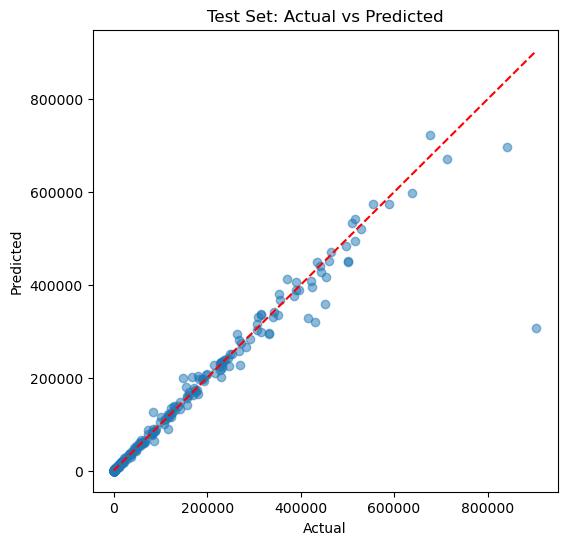

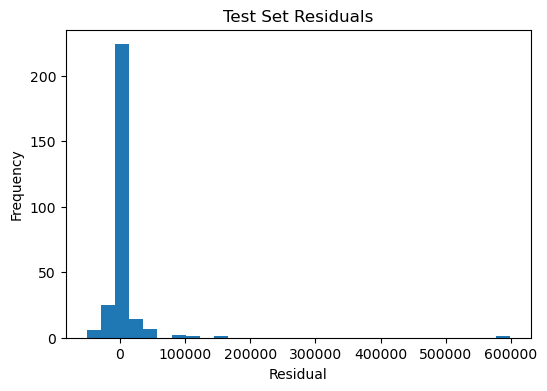

In [28]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {'R2': r2, 'MSE': mse, 'RMSE': rmse, 'MAE': mae}
    print(f"{name}: R2={r2:.4f}, MSE={mse:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}")

# Visualize predictions vs actuals
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Test Set: Actual vs Predicted')
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Test Set Residuals')
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
selector = SelectKBest(score_func=f_regression, k=30)  # You can change k
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
selected_feature_names = X.columns[selector.get_support()]

In [32]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='r2')
    print(f"{name} 5-fold CV R2: {scores.mean():.4f} ± {scores.std():.4f}")

Random Forest 5-fold CV R2: 0.8691 ± 0.2237
Gradient Boosting 5-fold CV R2: 0.8718 ± 0.2296
ElasticNet 5-fold CV R2: 0.9137 ± 0.1272
XGBoost 5-fold CV R2: 0.8371 ± 0.2082


In [33]:
print(master_df_enhanced['enhanced_engagement_score'].mean())
print(master_df_enhanced['enhanced_engagement_score'].median())

124701.28659072118
46006.975975646026
